Ce projet consiste a analyser les données de crédit allemandes afin de prédire la solvabilité des clients.


## 1. Exploration des données


analystics -> feat eng -> mod -> web app

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyparsing import alphas
from requests.packages import target


In [72]:
pd.set_option('display.max_columns', None)

In [73]:
# Applique un thème sombre global à Matplotlib
plt.style.use('dark_background')

# Puis configure Seaborn par-dessus
sns.set_style("darkgrid")

In [74]:
df = pd.read_csv('data/german_credit_data.csv')
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [75]:
df.Risk.value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [76]:
df["Saving accounts"].unique()

<ArrowStringArray>
[nan, 'little', 'quite rich', 'rich', 'moderate']
Length: 5, dtype: str

In [77]:
df["Checking account"].unique()

<ArrowStringArray>
['little', 'moderate', nan, 'rich']
Length: 4, dtype: str

In [78]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [80]:
df = df.dropna().reset_index(drop=True)

In [81]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [82]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [83]:
df.drop(columns=['Unnamed: 0'], inplace=True)

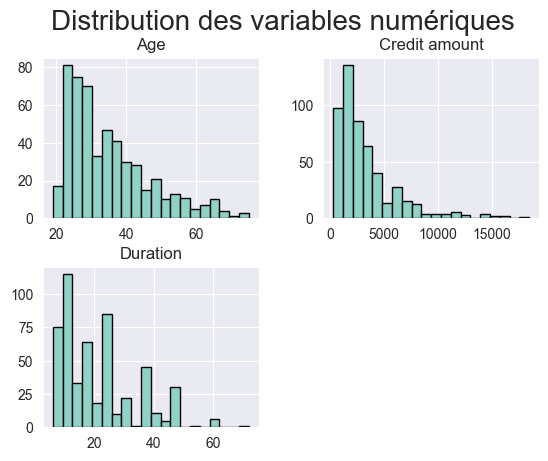

In [84]:
df[['Age', 'Credit amount', 'Duration']].hist(bins=20, edgecolor='black')
plt.suptitle('Distribution des variables numériques', fontsize=20)
plt.show()

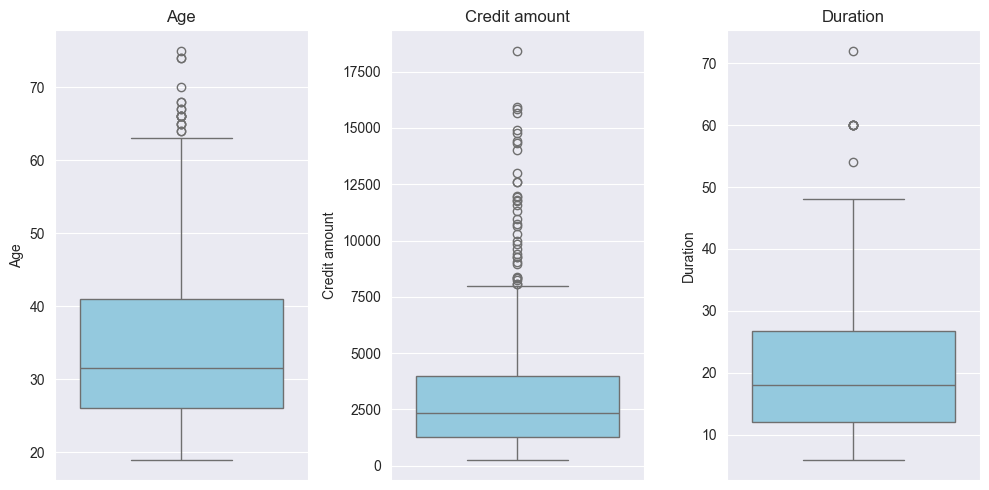

In [85]:
plt.figure(figsize=[10, 5])
for i, col in enumerate(['Age', 'Credit amount', 'Duration']):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()

In [86]:
categorical_cols = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

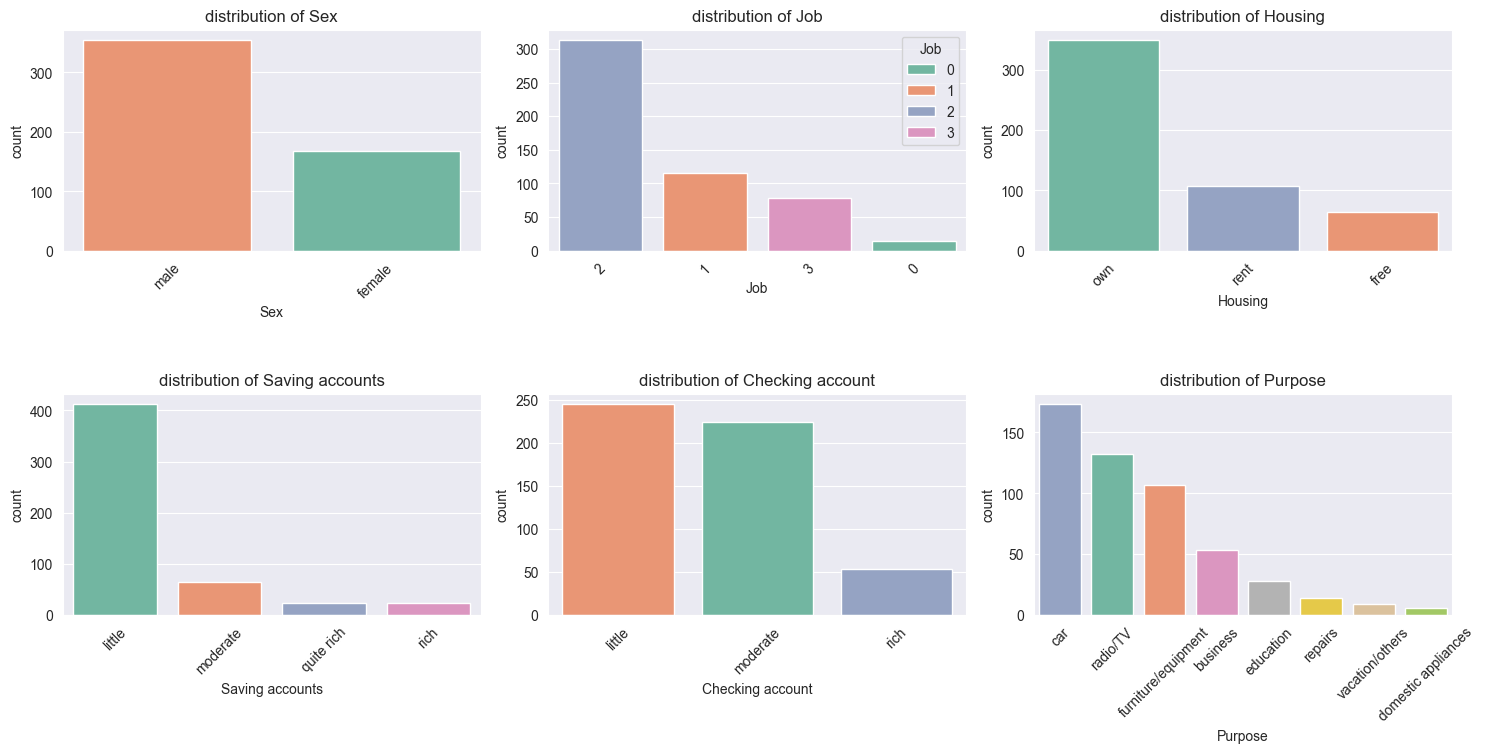

In [87]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(
        data=df,
        x=col,
        hue=col,
        palette='Set2',
        order=df[col].value_counts().index
    )
    plt.title(f'distribution of {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [88]:
corr = df[['Age', 'Job', 'Credit amount', 'Duration']].corr()
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


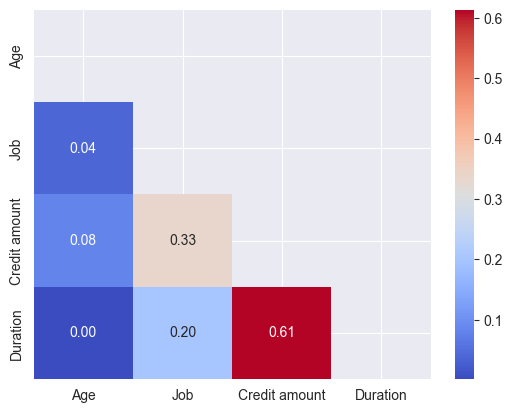

In [89]:
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', mask=mask)
plt.show()

In [90]:
df.groupby('Job')['Credit amount'].mean().sort_values(ascending=False)

Job
3    5648.784810
2    3129.130990
1    2250.715517
0    1767.857143
Name: Credit amount, dtype: float64

In [91]:
df.groupby('Sex')['Credit amount'].mean().sort_values(ascending=False)

Sex
male      3440.833333
female    2937.202381
Name: Credit amount, dtype: float64

In [92]:
pd.pivot_table(df, values='Credit amount', index='Housing', columns='Purpose')

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


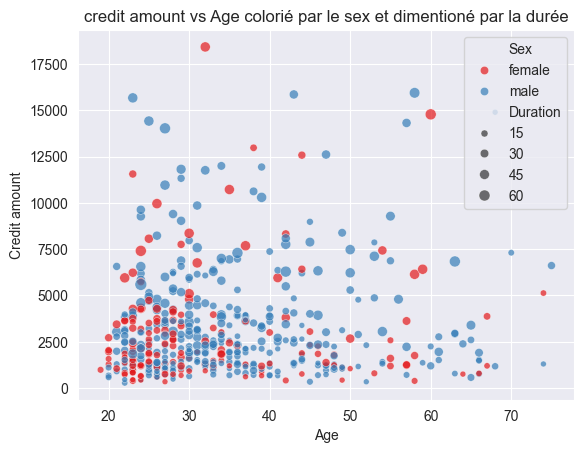

In [93]:
sns.scatterplot(df, x='Age', y='Credit amount', hue='Sex', size='Duration', alpha=0.7, palette='Set1')
plt.title('credit amount vs Age colorié par le sex et dimentioné par la durée')
plt.show()

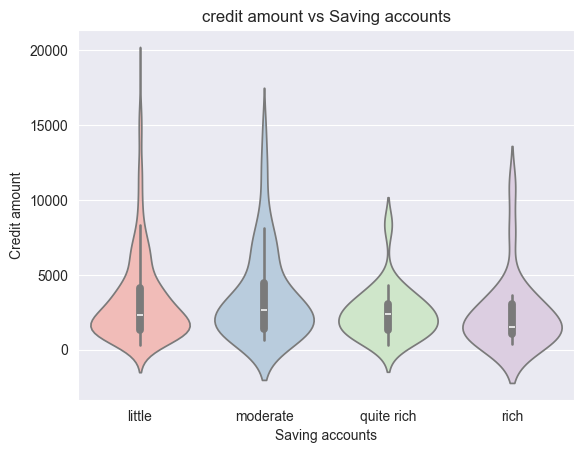

In [94]:
sns.violinplot(df, x='Saving accounts', hue='Saving accounts', y='Credit amount', palette='Pastel1')
plt.title('credit amount vs Saving accounts')
plt.show()

In [95]:
df.Risk.value_counts(normalize=True) * 100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

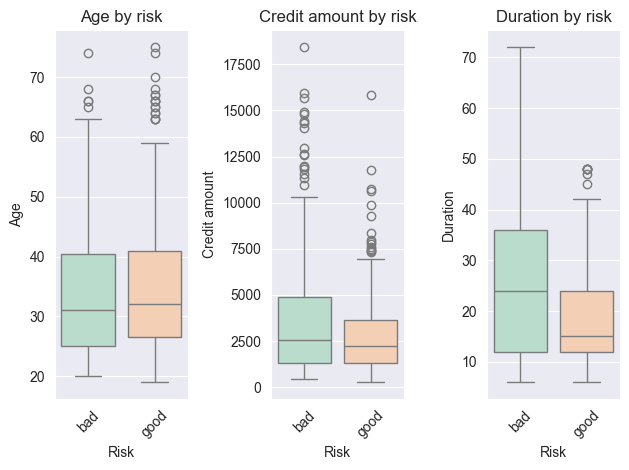

In [96]:
for i, col in enumerate(['Age', 'Credit amount', 'Duration']):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=df, x='Risk', hue='Risk', y=col, palette='Pastel2')
    plt.title(f'{col} by risk')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [97]:
df.groupby('Risk')[['Age', 'Credit amount', 'Duration']].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


In [98]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [99]:
features = ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount','Duration']
target = 'Risk'

In [100]:
df_model = df[features + [target]].copy()

In [101]:
df_model.head()


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [102]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [103]:
#choisir les colones avec des string ou etant des objets
cat_cols = df_model.select_dtypes(include=['object', 'string']).columns.drop('Risk')

In [104]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='str')

In [105]:
le_dic = {}

In [106]:
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dic[col] = le
    joblib.dump(le, 'models/' + col + '.pkl')

In [107]:
le_target = LabelEncoder()

In [108]:
df_model[target] = le_target.fit_transform(df_model[target])

In [109]:
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [110]:
joblib.dump(le_target, 'models/target_encoder.pkl')

['models/target_encoder.pkl']

In [111]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [112]:
from sklearn.model_selection import train_test_split

In [113]:
x = df_model.drop(target, axis=1)

In [114]:
y = df_model[target]

In [115]:
x


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,22,0,2,1,0,1,5951,48
1,45,1,2,0,0,0,7882,42
2,53,1,2,0,0,0,4870,24
3,35,1,3,2,0,1,6948,36
4,28,1,3,1,0,1,5234,30
...,...,...,...,...,...,...,...,...
517,48,1,1,1,0,1,1743,24
518,30,1,3,1,0,0,3959,36
519,40,1,3,1,0,0,3857,30
520,23,1,2,0,0,0,1845,45


In [116]:
x_tain, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, stratify=y, random_state=1)

In [117]:
x_tain.shape

(469, 8)

In [118]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [119]:
def train_model(model, param_grid, x_train, y_train, x_test, y_test):
    grid = GridSearchCV(model, param_grid, cv = 5, scoring='accuracy', n_jobs=-1)
    grid.fit(x_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    return best_model, acc, grid.best_params_

In [120]:
dt = DecisionTreeClassifier(random_state=1, class_weight='balanced')
dt_param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split" : [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4]
}

In [121]:
best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, x_tain, y_train, x_test, y_test)


In [122]:
print('decision tree accurency', acc_dt)

decision tree accurency 0.4716981132075472


In [123]:
print("best parameters", params_dt)

best parameters {'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [124]:
rf = RandomForestClassifier(random_state=1, class_weight='balanced', n_jobs=-1)

In [125]:
rf_param_grid = {
    "n_estimators" : [100, 200],
    "max_depth": [5, 7, 10, None],
    "min_samples_split" : [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4]
}

In [126]:
best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, x_tain, y_train, x_test, y_test)

In [127]:
print(f'randon forest accuracy', acc_rf)

randon forest accuracy 0.5660377358490566


In [128]:
print(f'Best params', params_rf)

Best params {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [129]:
et = ExtraTreesClassifier(random_state=1, class_weight='balanced', n_jobs=-1)

In [130]:
et_param_grid = {
    "n_estimators" : [100, 200],
    "max_depth": [5, 7, 10, None],
    "min_samples_split" : [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4]
}

In [131]:
best_et, acc_et, params_et = train_model(rf, rf_param_grid, x_tain, y_train, x_test, y_test)

In [132]:
print(f'extra tree accuracy', acc_et)

extra tree accuracy 0.5660377358490566


In [133]:
print(f'Best params', params_et)

Best params {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [134]:
xgb = XGBClassifier(random_state=1, scale_pos_weight= (y_train == 0).sum() / (y_train == 1).sum(), use_label_encoder=False, eval_metric='logloss')

In [135]:
xgb_param_grid = {
    "n_estimators" : [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate" : [0.01, 0.1, 0.2],
    "subsample" : [0.7, 1],
    "colsample_bytree" : [0.7, 1],
}

In [136]:
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid, x_tain, y_train, x_test, y_test)

C:\Users\HP\PycharmProjects\tuto1\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:28:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [137]:
print(f'xgb accuracy', acc_xgb)

xgb accuracy 0.6037735849056604


In [138]:
print(f'best params', params_xgb)

best params {'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1}


In [139]:
best_et.predict(x_test)

array([0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1])

In [140]:
joblib.dump(best_et, 'models/extra_tree_credit_model.pkl')

['models/extra_tree_credit_model.pkl']